In [1]:
import xarray as xr 
import glob
import torch 
import matplotlib.pyplot as plt
import numpy as np
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [3]:
# IG = np.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/1981-02-15/tensor_steps24_parrallel_lev00020_lat00149_lon00096.npy')

In [5]:
# IG_s = IG.squeeze()

# # Largest absolute gradient anywhere in each level
# level_abs_max = np.nanmax(np.abs(IG_s), axis=(1, 2))

# # Top 5 levels, sorted from largest to smaller
# top5_levels = np.argsort(level_abs_max)[-5:][::-1]

# for rank, lev in enumerate(top5_levels, start=1):
#     ilat, ilon = np.unravel_index(
#         np.nanargmax(np.abs(IG_s[lev, :, :])),
#         IG_s[lev, :, :].shape,
#     )

#     signed_value = IG_s[lev, ilat, ilon]
#     abs_value = np.abs(signed_value)

#     print(f"Rank {rank}")
#     print("Level:", lev)
#     print("Signed value:", signed_value)
#     print("Absolute value:", abs_value)
#     print("Lat index:", ilat)
#     print("Lon index:", ilon)
#     print()

In [12]:
DATE = '1981-02-15'

DS = xr.open_dataset('/glade/work/wchapman/b.e21.BHIST.f09_g17_Seasonal_Stochai_b050_025_1980.cam.h1.2010-10-13-00000.nc') 
lat = DS["lat"].values if hasattr(DS["lat"], "values") else DS["lat"]
lon = DS["lon"].values if hasattr(DS["lon"], "values") else DS["lon"]

dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/"+DATE+"/"
files = sorted(glob.glob(dir_o+"tensor_steps24_parrallel_lev00020_lat*.npy"))
stacked = np.stack([np.load(f).squeeze()[20].squeeze() for f in files])

mean_IG = np.mean(stacked, axis=0)

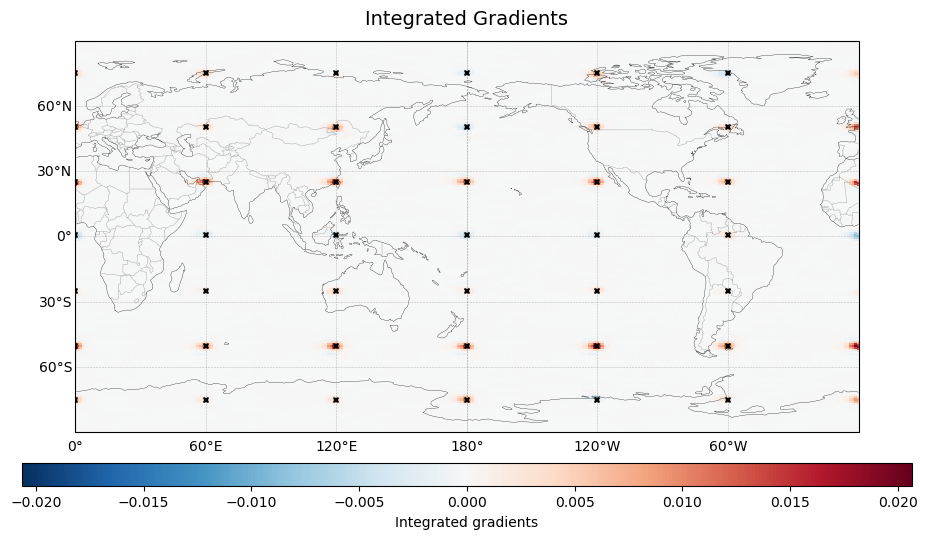

In [13]:
# IG = np.load(dir_o + "tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy").squeeze()
# field_show = IG[20, :, :].squeeze()

# field_cyc, lon_cyc = add_cyclic_point(field_show, coord=lon)
field_cyc, lon_cyc = add_cyclic_point(mean_IG, coord=lon)

vmax = np.nanmax(np.abs(field_cyc))
vmin = -vmax

fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

im = ax.pcolormesh(
    lon_cyc,
    lat,
    field_cyc,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Integrated gradients")

ax.set_title("Integrated Gradients", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

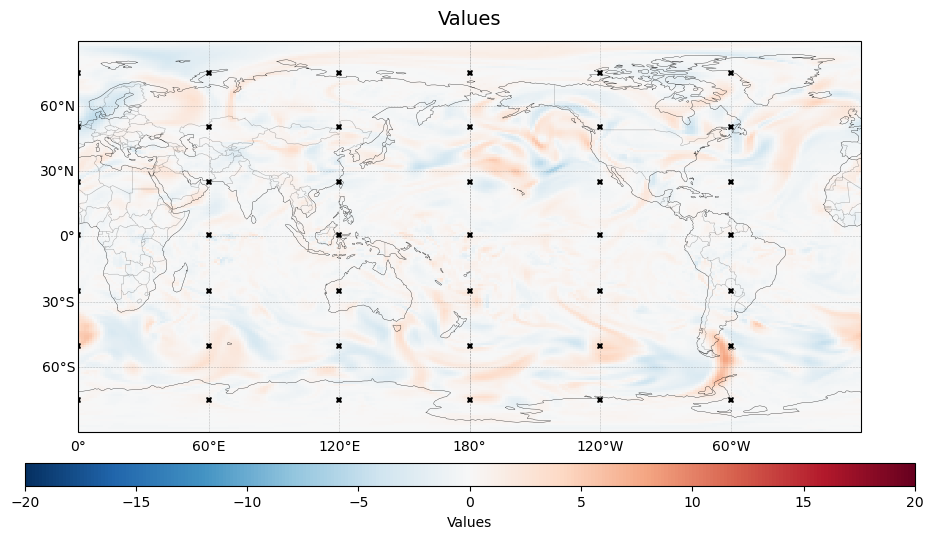

In [15]:
# Difference in values between 00Z and 006Z
t1 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_b2014_1981-02-15_00_00_00_be21_condition_tensor.pth').squeeze().numpy()
t2 = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_b2014_1981-02-15_06_00_00_be21_condition_tensor.pth').squeeze().numpy()


fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
vmin=-20; vmax=20
im = ax.pcolormesh(
    lon_cyc,
    lat,
    t2[17+64,:,:]-t1[17+64,:,:],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Values")

ax.set_title("Values", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

In [26]:
t1 = torch.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-02-15_00_00_00_be21_condition_tensor.pth').squeeze().numpy()
t1[17+64,:,:]

array([[-1.1896183 , -1.1896183 , -1.1896183 , ..., -1.1896183 ,
        -1.1896183 , -1.1896183 ],
       [-1.1856134 , -1.184724  , -1.1840085 , ..., -1.1883134 ,
        -1.1875011 , -1.186593  ],
       [-1.1380801 , -1.1352531 , -1.1325928 , ..., -1.1464008 ,
        -1.1438751 , -1.1410195 ],
       ...,
       [-1.0249126 , -1.0212257 , -1.0175633 , ..., -1.036063  ,
        -1.0323467 , -1.0286266 ],
       [-0.98062927, -0.97923595, -0.9778426 , ..., -0.9847381 ,
        -0.9833756 , -0.9820039 ],
       [-0.9505733 , -0.9505733 , -0.9505733 , ..., -0.9505733 ,
        -0.9505733 , -0.9505733 ]], dtype=float32)

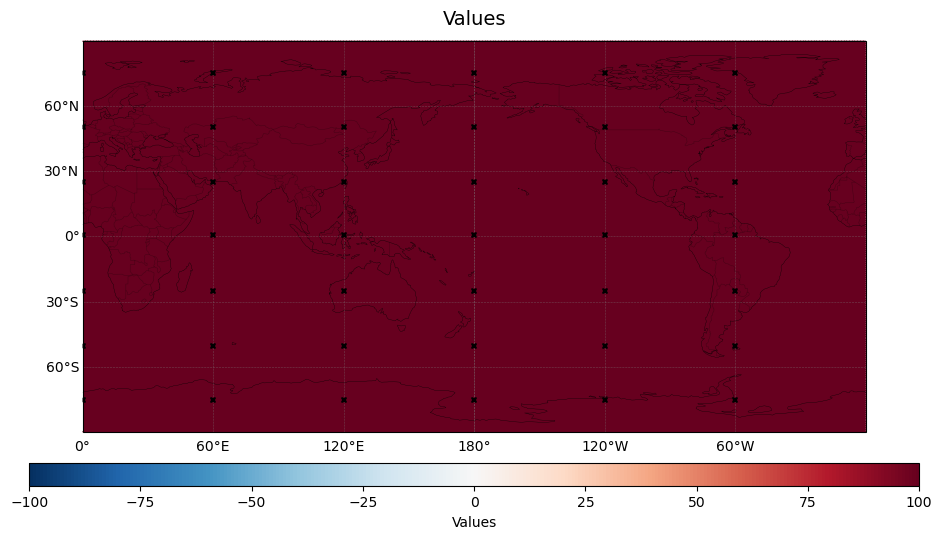

In [21]:
# Difference in values between 00Z and associated climatology
climo = torch.load('/glade/derecho/scratch/wchapman/CUVACAR/init_1981-02-15_00_00_00_be21_condition_tensor_baseline.pth').squeeze().numpy()
t1 = torch.load('/glade/derecho/scratch/kjmayer/CUVACAR_xai/init_b2014_1981-02-15_00_00_00_be21_condition_tensor.pth').squeeze().numpy()


fig = plt.figure(figsize=(12, 5.5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
vmin=-100; vmax=100
im = ax.pcolormesh(
    lon_cyc,
    lat,
    t1[17+64,:,:]-climo[17+64,:,:],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

lat_idx = [16, 42, 69, 96, 122, 149, 175]
lon_idx = [0, 48, 96, 144, 192, 240]

dot_lat = lat[lat_idx]
dot_lon = lon_cyc[lon_idx]

for vdot_lat in dot_lat:
    for vdot_lon in dot_lon:
        ax.plot(
            vdot_lon,
            vdot_lat,
            marker="X",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0,
            transform=ccrs.PlateCarree(),
            zorder=10,
        )

ax.set_global()
ax.coastlines(linewidth=0.22)
ax.add_feature(cfeature.BORDERS, linewidth=0.35, alpha=0.3)
# ax.add_feature(cfeature.LAND, facecolor="0.85", alpha=0.35)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
    aspect=40,
)
cbar.set_label("Values")

ax.set_title("Values", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

In [51]:
# input concatenated tensor's indexes for each input variable

# U = input_tensor[0:32]
# V = input_tensor[32:64]
# T = input_tensor[64:96]
# Q = input_tensor[96:128]

# TREFHT = input_tensor[129]
# PS = input_tensor[128]

# co2mr_3d = input_tensor[-1]
# ICEFRAC = input_tensor[-2]
# SST = input_tensor[-3]
# SOLIN = input_tensor[-4]
# LANDM_COSLAT = input_tensor[-5]
# z_norm = input_tensor[-6]

In [7]:
dir_o = "/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/"
files = sorted(glob.glob(dir_o+"*/tensor_steps24_parrallel_lev00020_lat00122_lon00144.npy"))
stackeddate = np.stack([np.load(f).squeeze() for f in files])

meandate_IG = np.mean(stackeddate, axis=0)

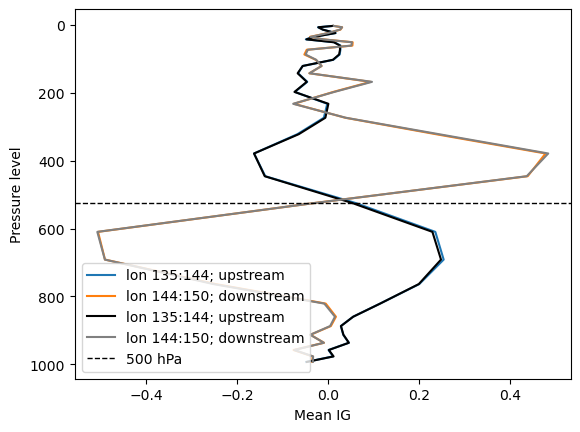

In [10]:
# U, V, T, Q: addval = 0, 32, 64, 96

addval = 64
plt.plot(
    np.mean(np.mean(meandate_IG[0+addval:32+addval, 118:126, 135:144], axis=1), axis=1),
    DS["lev"].values,
    label="lon 135:144; upstream")

plt.plot(
    np.mean(np.mean(meandate_IG[0+addval:32+addval, 118:126, 144:150], axis=1), axis=1),
    DS["lev"].values,
    label="lon 144:150; downstream")

plt.plot(
    np.mean(np.mean(stackeddate[45,0+addval:32+addval, 118:126, 135:144], axis=1), axis=1),
    DS["lev"].values,
    label="lon 135:144; upstream", color='k')

plt.plot(
    np.mean(np.mean(stackeddate[45,0+addval:32+addval, 118:126, 144:150], axis=1), axis=1),
    DS["lev"].values,
    label="lon 144:150; downstream",color='grey')


plt.axhline(
    y=524.6871747076511,
    color="k",
    linestyle="--",
    linewidth=1,
    label="500 hPa",
)

plt.gca().invert_yaxis()
plt.xlabel("Mean IG")
plt.ylabel("Pressure level")
plt.legend()

plt.show()